In [11]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.6 MB/s eta 0:00:00


🔷 Step 1: Autoencoder Training सुरू...


Model: "LoginAnomalyDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,610 (25.82 KB)

 Trainable params: 6,354 (24.82 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2408 - mae: 0.4423 - val_loss: 0.2096 - val_mae: 0.4371
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.2260 - mae: 0.4419 - val_loss: 0.2089 - val_mae: 0.4365
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.2369 - mae: 0.4429 - val_loss: 0.2083 - val_mae: 0.4359
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.2495 - mae: 0.4635 - val_loss: 0.2079 - val_mae: 0.4355
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.2193 - mae: 0.4351 - val_loss: 0.2075 - val_mae: 0.4352
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.2440 - mae: 0.4574 - val_loss: 0.2070 - val_mae: 0.4348
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.2119 - mae: 0.4239 - val_loss: 0.2065 - val_mae: 0.4343
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.2281 - mae: 0.4445 - val_loss: 0.2060 - val_mae: 0.4338
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.2107 -

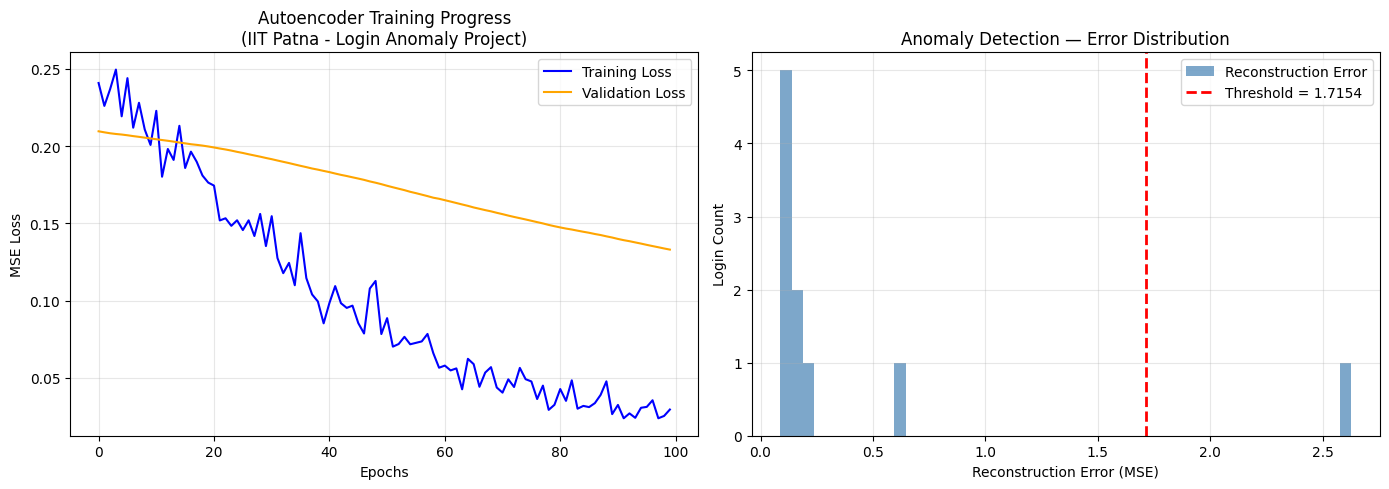

✅ Graph saved: anomaly_detection_results.png

✅ Model save करत आहे...
💾 Model saved: login_anomaly_autoencoder.keras
💾 Scaler saved: scaler.pkl


In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib

# ══════════════════════════════════════════════
# STEP 1: डेटा तयार करणे (Feature Engineering)
# ══════════════════════════════════════════════

def prepare_login_features(df):
    """
    Login डेटामधून महत्त्वाचे features काढणे
    """
    features = pd.DataFrame()

    # वेळेशी संबंधित features
    features['hour_of_day'] = df['timestamp'].dt.hour
    features['day_of_week'] = df['timestamp'].dt.dayofweek
    features['is_weekend'] = (features['day_of_week'] >= 5).astype(int)
    features['is_night'] = ((features['hour_of_day'] < 6) |
                             (features['hour_of_day'] > 22)).astype(int)

    # Login behavior features
    features['failed_attempts'] = df['failed_attempts']
    features['login_frequency'] = df['login_frequency']  # प्रति तास
    features['session_duration'] = df['session_duration']  # मिनिटांत

    # Network features
    features['is_new_ip'] = df['is_new_ip'].astype(int)
    features['is_new_device'] = df['is_new_device'].astype(int)
    features['geo_anomaly'] = df['geo_anomaly'].astype(int)  # नवीन देश/शहर

    return features

# ══════════════════════════════════════════════
# STEP 2: Autoencoder Model तयार करणे
# ══════════════════════════════════════════════

def build_autoencoder(input_dim, encoding_dim=8):
    """
    Stacked Autoencoder Architecture
    IIT Patna - Deep Learning Module नुसार
    """
    # --- Encoder ---
    input_layer = Input(shape=(input_dim,), name='input')

    x = Dense(64, activation='relu', name='enc_1')(input_layer)
    x = BatchNormalization(name='bn_1')(x)          # Training stable करण्यासाठी
    x = Dropout(0.2, name='drop_1')(x)              # Overfitting टाळण्यासाठी

    x = Dense(32, activation='relu', name='enc_2')(x)
    x = BatchNormalization(name='bn_2')(x)

    # Bottleneck Layer — येथे compressed representation तयार होते
    bottleneck = Dense(encoding_dim, activation='relu', name='bottleneck')(x)

    # --- Decoder (Mirror of Encoder) ---
    x = Dense(32, activation='relu', name='dec_1')(bottleneck)
    x = BatchNormalization(name='bn_3')(x)

    x = Dense(64, activation='relu', name='dec_2')(x)
    x = Dropout(0.2, name='drop_2')(x)

    # Output — sigmoid कारण features 0-1 range मध्ये normalize केलेले आहेत
    output_layer = Dense(input_dim, activation='sigmoid', name='output')(x)

    # Model compile
    autoencoder = Model(inputs=input_layer, outputs=output_layer,
                        name='LoginAnomalyDetector')
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return autoencoder

# ══════════════════════════════════════════════
# STEP 3: Training — फक्त Normal Data वर
# ══════════════════════════════════════════════

def train_autoencoder(X_normal):
    """
    महत्त्वाचे: फक्त Normal login data वर train करणे
    Anomaly data train मध्ये असता कामा नये!
    """
    # Normalization (0 ते 1 range)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_normal)

    # Train-Validation split
    X_train, X_val = train_test_split(X_scaled, test_size=0.15, random_state=42)

    # Model तयार करणे
    model = build_autoencoder(input_dim=X_train.shape[1], encoding_dim=8)
    model.summary()  # Architecture पाहण्यासाठी

    # Callbacks — Training Smart बनवण्यासाठी
    callbacks = [
        # Validation loss सुधारत नसेल तर थांबणे
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        # सर्वोत्तम model save करणे
        ModelCheckpoint('best_autoencoder.keras', save_best_only=True)
    ]

    # Training
    history = model.fit(
        X_train, X_train,           # Input = Output (self-supervised!)
        validation_data=(X_val, X_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    return model, scaler, history

# ══════════════════════════════════════════════
# STEP 4: Threshold ठरवणे आणि Anomaly Detection
# ══════════════════════════════════════════════

def detect_anomalies(model, scaler, X_test, percentile=95):
    """
    Reconstruction Error वर आधारित Anomaly Detection

    percentile=95 म्हणजे: 95% normal logins च्या वरील error = Anomaly
    """
    # Test data normalize करणे
    X_test_scaled = scaler.transform(X_test)

    # Reconstruction करणे
    X_reconstructed = model.predict(X_test_scaled)

    # Reconstruction Error (MSE) प्रत्येक login साठी
    reconstruction_errors = np.mean(
        np.power(X_test_scaled - X_reconstructed, 2),
        axis=1
    )

    # Threshold — Normal data च्या distribution वरून ठरवणे
    threshold = np.percentile(reconstruction_errors, percentile)

    # Anomaly Flag
    predictions = (reconstruction_errors > threshold).astype(int)
    # 0 = Normal, 1 = Anomaly

    return predictions, reconstruction_errors, threshold

# ══════════════════════════════════════════════
# STEP 5: Results Visualize करणे
# ══════════════════════════════════════════════

def plot_results(history, reconstruction_errors, threshold):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training Loss
    axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
    axes[0].set_title('Autoencoder Training Progress\n(IIT Patna - Login Anomaly Project)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Reconstruction Error Distribution
    axes[1].hist(reconstruction_errors, bins=50, color='steelblue',
                 alpha=0.7, label='Reconstruction Error')
    axes[1].axvline(threshold, color='red', linestyle='--',
                    linewidth=2, label=f'Threshold = {threshold:.4f}')
    axes[1].set_title('Anomaly Detection — Error Distribution')
    axes[1].set_xlabel('Reconstruction Error (MSE)')
    axes[1].set_ylabel('Login Count')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graph saved: anomaly_detection_results.png")

# ══════════════════════════════════════════════
# MAIN — सर्व एकत्र चालवणे
# ══════════════════════════════════════════════

if __name__ == "__main__":

    # तुमचा data load करा
    # df = pd.read_csv('login_data.csv')
    # df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Creating a dummy DataFrame for demonstration
    data = {
        'timestamp': pd.to_datetime(['2023-01-01 08:00:00', '2023-01-01 09:00:00', '2023-01-01 10:00:00', '2023-01-01 11:00:00', '2023-01-01 12:00:00',
                                   '2023-01-02 14:00:00', '2023-01-02 15:00:00', '2023-01-02 16:00:00', '2023-01-02 23:00:00', '2023-01-03 03:00:00']),
        'failed_attempts': [0, 0, 0, 1, 0, 0, 0, 0, 5, 2],
        'login_frequency': [1, 1, 2, 1, 1, 1, 2, 1, 1, 1],
        'session_duration': [10, 15, 20, 5, 12, 18, 25, 10, 3, 7],
        'is_new_ip': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        'is_new_device': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        'geo_anomaly': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        'label': ['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'anomaly', 'anomaly'] # Add labels for demonstration
    }
    df = pd.DataFrame(data)

    # Feature preparation
    X = prepare_login_features(df)
    X_normal = X[df['label'] == 'normal']  # फक्त normal data
    X_test = X # For demonstration, using all data as test data

    print("🔷 Step 1: Autoencoder Training सुरू...")
    model, scaler, history = train_autoencoder(X_normal)

    print("\n🔷 Step 2: Anomaly Detection...")
    predictions, errors, threshold = detect_anomalies(model, scaler, X_test)

    anomaly_count = predictions.sum()
    print(f"\n📊 परिणाम:")
    print(f"   एकूण Logins: {len(predictions)}")
    print(f"   Anomalies सापडल्या: {anomaly_count}")
    print(f"   Anomaly Rate: {anomaly_count/len(predictions)*100:.2f}%")
    print(f"   Threshold (MSE): {threshold:.6f}")

    print("\n🔷 Step 3: Results Visualize करत आहे...")
    plot_results(history, errors, threshold)

    print("\n✅ Model save करत आहे...")
    model.save('login_anomaly_autoencoder.keras')
    joblib.dump(scaler, 'scaler.pkl') # Save the scaler
    print("💾 Model saved: login_anomaly_autoencoder.keras")
    print("💾 Scaler saved: scaler.pkl")

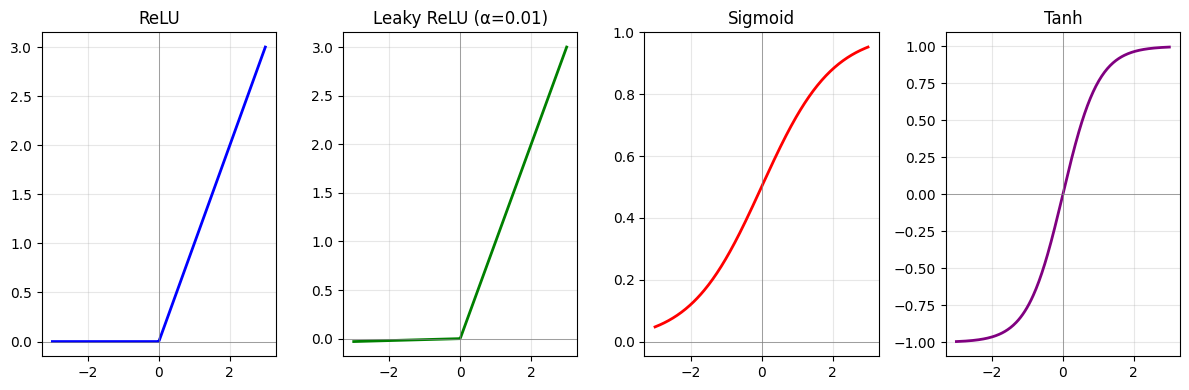

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# ReLU manually
def relu(x):
    return np.maximum(0, x)

# Leaky ReLU — Dying Neuron Problem सोडवते
def leaky_relu(x, alpha=0.01):
    # alpha=0.01 म्हणजे negative values पूर्णपणे मरत नाहीत
    return np.where(x > 0, x, alpha * x)

# Sigmoid — Output Layer साठी (0 ते 1 range)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh — (-1 ते 1 range)
def tanh(x):
    return np.tanh(x)

# Visualization
x = np.linspace(-3, 3, 300)
plt.figure(figsize=(12, 4))

functions = {
    'ReLU': relu(x),
    'Leaky ReLU (α=0.01)': leaky_relu(x),
    'Sigmoid': sigmoid(x),
    'Tanh': tanh(x)
}

for i, (name, y) in enumerate(functions.items(), 1):
    plt.subplot(1, 4, i)
    plt.plot(x, y, linewidth=2, color=['blue','green','red','purple'][i-1])
    plt.title(name)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150)
plt.show()

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense,
                                      RepeatVector, TimeDistributed,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# ══════════════════════════════════════════════
# STEP 1: Login Sequences तयार करणे
# ══════════════════════════════════════════════

def create_sequences(data, seq_length=10):
    """
    Login events ना time-sequences मध्ये रूपांतरित करणे

    उदाहरण: seq_length=10 म्हणजे 10 consecutive logins चा एक sample

    Input shape:  (total_logins, features)
    Output shape: (samples, seq_length, features)
    """
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i : i + seq_length])
    return np.array(sequences)

# ══════════════════════════════════════════════
# STEP 2: LSTM Autoencoder Architecture
# ══════════════════════════════════════════════

def build_lstm_autoencoder(seq_length, n_features, encoding_dim=32):
    """
    LSTM Autoencoder Architecture:

    Encoder: sequence → compressed vector
    Decoder: compressed vector → reconstructed sequence

    Input:  (batch, seq_length, n_features)
    Output: (batch, seq_length, n_features)
    """
    inputs = Input(shape=(seq_length, n_features), name='sequence_input')

    # ── Encoder ──────────────────────────────
    # return_sequences=True: प्रत्येक time step चा output द्या
    x = LSTM(64, activation='tanh', return_sequences=True,
             name='lstm_enc_1')(inputs)

    # return_sequences=False: फक्त शेवटचा output द्या (bottleneck साठी)
    encoded = LSTM(encoding_dim, activation='tanh', return_sequences=False,
                   name='lstm_bottleneck')(x)

    # ── Bridge ───────────────────────────────
    # Compressed vector ला seq_length वेळा repeat करणे
    # (batch, encoding_dim) → (batch, seq_length, encoding_dim)
    repeated = RepeatVector(seq_length, name='repeat')(encoded)

    # ── Decoder ──────────────────────────────
    x = LSTM(encoding_dim, activation='tanh', return_sequences=True,
             name='lstm_dec_1')(repeated)
    x = LSTM(64, activation='tanh', return_sequences=True,
             name='lstm_dec_2')(x)

    # TimeDistributed: प्रत्येक time step वर Dense layer लावणे
    outputs = TimeDistributed(Dense(n_features, activation='sigmoid'),
                              name='reconstruction')(x)

    model = Model(inputs=inputs, outputs=outputs, name='LSTM_Autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return model

# ══════════════════════════════════════════════
# STEP 3: Training आणि Detection
# ══════════════════════════════════════════════

def train_and_detect_lstm(X_normal_raw, X_test_raw, seq_length=10):

    # Normalization
    scaler = MinMaxScaler()
    X_normal_scaled = scaler.fit_transform(X_normal_raw)
    X_test_scaled   = scaler.transform(X_test_raw)

    # Sequences तयार करणे
    X_normal_seq = create_sequences(X_normal_scaled, seq_length)
    X_test_seq   = create_sequences(X_test_scaled, seq_length)

    print(f"Training sequences shape: {X_normal_seq.shape}")
    # उदाहरण: (9000, 10, 8) → 9000 samples, 10 time steps, 8 features

    n_features = X_normal_seq.shape[2]

    # Model build
    model = build_lstm_autoencoder(seq_length, n_features, encoding_dim=32)
    model.summary()

    # Training
    history = model.fit(
        X_normal_seq, X_normal_seq,   # self-supervised
        epochs=100,
        batch_size=64,
        validation_split=0.15,
        callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
        verbose=1
    )

    # Anomaly Detection
    X_test_reconstructed = model.predict(X_test_seq)

    # प्रत्येक sequence चा MSE
    mse_per_sequence = np.mean(
        np.power(X_test_seq - X_test_reconstructed, 2),
        axis=(1, 2)   # time steps आणि features दोन्हींवर average
    )

    threshold = np.percentile(mse_per_sequence, 95)
    anomalies  = mse_per_sequence > threshold

    print(f"\n📊 LSTM Results:")
    print(f"   Threshold: {threshold:.6f}")
    print(f"   Anomalous Sequences: {anomalies.sum()} / {len(anomalies)}")

    return model, scaler, threshold, mse_per_sequence

In [9]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Lambda

# ══════════════════════════════════════════════
# VAE — Sampling Layer (Reparameterization Trick)
# ══════════════════════════════════════════════

def sampling(args):
    """
    Reparameterization Trick:
    z = μ + σ × ε   (ε ~ N(0,1))

    हे backpropagation शक्य करते random sampling असतानाही!
    """
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim   = K.shape(z_mean)[1]

    # Standard Normal distribution मधून random sample
    epsilon = K.random_normal(shape=(batch, dim), mean=0.0, stddev=1.0)

    # Reparameterization: z = μ + exp(log_var/2) × ε
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# ══════════════════════════════════════════════
# VAE Architecture
# ══════════════════════════════════════════════

def build_vae(input_dim, latent_dim=4):
    """
    VAE Loss = Reconstruction Loss + KL Divergence

    KL Divergence: Learned distribution आणि Normal(0,1) मधील अंतर
    """
    # ── Encoder ──────────────────────────────
    inputs = Input(shape=(input_dim,), name='vae_input')
    x = Dense(64, activation='relu')(inputs)
    x = Dense(32, activation='relu')(x)

    # Mean आणि Log Variance (Distribution Parameters)
    z_mean    = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)

    # Sampling Layer
    z = Lambda(sampling, output_shape=(latent_dim,),
               name='z_sampling')([z_mean, z_log_var])

    # ── Decoder ──────────────────────────────
    x = Dense(32, activation='relu')(z)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(input_dim, activation='sigmoid', name='vae_output')(x)

    # ── VAE Model ────────────────────────────
    vae = Model(inputs, outputs, name='VAE')

    # Custom VAE Loss = Reconstruction + KL Divergence
    def vae_loss(y_true, y_pred):
        # Reconstruction Loss (Binary Crossentropy)
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y_true, y_pred)
        ) * input_dim

        # KL Divergence Loss
        # = -0.5 × Σ(1 + log(σ²) - μ² - σ²)
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        return recon_loss + kl_loss

    vae.compile(optimizer='adam', loss=vae_loss)
    return vae, z_mean, z_log_var

# ══════════════════════════════════════════════
# VAE Anomaly Score — Probabilistic!
# ══════════════════════════════════════════════

def vae_anomaly_score(vae, z_mean_model, z_log_var_model, X_test_scaled):
    """
    VAE चा फायदा: फक्त "होय/नाही" नाही,
    तर प्रत्येक login साठी PROBABILITY score मिळतो!
    """
    # Reconstruction
    reconstructions = vae.predict(X_test_scaled)

    # Reconstruction Error
    recon_error = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

    # KL Divergence Score (latent space मधील "असामान्यता")
    # जितका जास्त KL Score, तितका जास्त Anomalous

    # Anomaly Score = Reconstruction Error (simple but effective)
    anomaly_scores = recon_error

    # Normalize करून 0-100 range मध्ये आणा
    min_s, max_s = anomaly_scores.min(), anomaly_scores.max()
    risk_scores = ((anomaly_scores - min_s) / (max_s - min_s)) * 100

    # Risk Level ठरवणे
    risk_labels = np.where(risk_scores > 80, 'HIGH RISK 🔴',
                  np.where(risk_scores > 50, 'MEDIUM RISK 🟡', 'LOW RISK 🟢'))

    return risk_scores, risk_labels

In [12]:
import keras_tuner as kt

# pip install keras-tuner

def build_tunable_autoencoder(hp):
    """
    hp (HyperParameters) object — Keras Tuner automatically values बदलतो
    """
    input_dim = 10  # तुमच्या features नुसार बदला

    inputs = Input(shape=(input_dim,))

    # ── Tunable Parameters ───────────────────

    # Layer 1 neurons: 32, 64, 128 मधून निवड
    units_1 = hp.Choice('units_layer1', values=[32, 64, 128])
    # Layer 2 neurons: 16, 32, 64 मधून निवड
    units_2 = hp.Choice('units_layer2', values=[16, 32, 64])
    # Bottleneck: 4 ते 16 मधून निवड
    bottleneck = hp.Int('bottleneck', min_value=4, max_value=16, step=4)
    # Learning Rate: log scale वर search
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    # Activation: relu किंवा leaky_relu
    activation = hp.Choice('activation', values=['relu', 'leaky_relu'])

    if activation == 'leaky_relu':
        act_fn = tf.keras.layers.LeakyReLU(alpha=0.01)
    else:
        act_fn = 'relu'

    # Model Architecture
    x = Dense(units_1, activation=act_fn)(inputs)
    x = Dense(units_2, activation=act_fn)(x)
    encoded = Dense(bottleneck, activation='relu')(x)
    x = Dense(units_2, activation=act_fn)(encoded)
    x = Dense(units_1, activation=act_fn)(x)
    outputs = Dense(input_dim, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse'
    )
    return model

def run_hyperparameter_tuning(X_train_normal):
    """
    Keras Tuner — Random Search Strategy
    """
    tuner = kt.RandomSearch(
        build_tunable_autoencoder,
        objective='val_loss',     # हे Minimize करायचे आहे
        max_trials=20,            # 20 वेगळे combinations try करणे
        executions_per_trial=2,   # Consistency साठी प्रत्येक 2 वेळा
        directory='tuning_logs',
        project_name='login_anomaly_tuning'
    )

    print("🔍 Hyperparameter Search सुरू...")
    tuner.search_space_summary()

    tuner.search(
        X_train_normal, X_train_normal,
        epochs=50,
        validation_split=0.2,
        callbacks=[EarlyStopping(patience=5)]
    )

    # सर्वोत्तम parameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    print("\n✅ सर्वोत्तम Hyperparameters सापडले:")
    print(f"   Layer 1 Units:    {best_hps.get('units_layer1')}")
    print(f"   Layer 2 Units:    {best_hps.get('units_layer2')}")
    print(f"   Bottleneck Size:  {best_hps.get('bottleneck')}")
    print(f"   Learning Rate:    {best_hps.get('learning_rate'):.6f}")
    print(f"   Activation:       {best_hps.get('activation')}")

    # सर्वोत्तम model build करणे
    best_model = tuner.hypermodel.build(best_hps)
    return best_model, best_hps

In [ ]:
import os

if os.path.exists('scaler.pkl'):
    print("scaler.pkl exists in the current directory.")
else:
    print("scaler.pkl does NOT exist in the current directory.")

In [ ]:
# app.py — Production-ready Flask API

from flask import Flask, request, jsonify
import numpy as np
import tensorflow as tf
import joblib
import time
from datetime import datetime

app = Flask(__name__)

# ══════════════════════════════════════════════
# Model एकदाच Load करणे (Startup वर)
# ══════════════════════════════════════════════

print("🔄 Model लोड होत आहे...")
model  = tf.keras.models.load_model('login_anomaly_autoencoder.keras')
scaler = joblib.load('scaler.pkl')
THRESHOLD = 0.045  # Training नंतर ठरवलेला threshold

print("✅ Model तयार! API सुरू करत आहे...")

# ══════════════════════════════════════════════
# API Endpoints
# ══════════════════════════════════════════════

@app.route('/health', methods=['GET'])
def health_check():
    """API चालू आहे का हे तपासण्यासाठी"""
    return jsonify({
        'status': 'healthy',
        'model': 'LoginAnomalyDetector v1.0',
        'timestamp': datetime.now().isoformat()
    })


@app.route('/detect', methods=['POST'])
def detect_anomaly():
    """
    एका Login event साठी Anomaly Detection

    Request JSON:
    {
        "user_id": "USR_001",
        "hour_of_day": 2,
        "day_of_week": 1,
        "is_weekend": 0,
        "is_night": 1,
        "failed_attempts": 5,
        "login_frequency": 12,
        "session_duration": 5,
        "is_new_ip": 1,
        "is_new_device": 1
    }
    """
    start_time = time.time()

    try:
        data = request.get_json()

        # Input Validation
        required_fields = [
            'hour_of_day', 'day_of_week', 'is_weekend', 'is_night',
            'failed_attempts', 'login_frequency', 'session_duration',
            'is_new_ip', 'is_new_device'
        ]

        missing = [f for f in required_fields if f not in data]
        if missing:
            return jsonify({
                'error': f'Missing fields: {missing}'
            }), 400

        # Feature Array तयार करणे
        features = np.array([[
            data['hour_of_day'],
            data['day_of_week'],
            data['is_weekend'],
            data['is_night'],
            data['failed_attempts'],
            data['login_frequency'],
            data['session_duration'],
            data['is_new_ip'],
            data['is_new_device']
        ]])

        # Normalize
        features_scaled = scaler.transform(features)

        # Predict
        reconstruction = model.predict(features_scaled, verbose=0)
        mse = float(np.mean(np.power(features_scaled - reconstruction, 2)))

        # Risk Score (0 ते 100)
        risk_score = min(100, (mse / (THRESHOLD * 2)) * 100)

        is_anomaly = mse > THRESHOLD

        # Risk Level
        if risk_score > 80:
            risk_level = "HIGH"
            action = "BLOCK_AND_ALERT"
        elif risk_score > 50:
            risk_level = "MEDIUM"
            action = "REQUIRE_MFA"
        else:
            risk_level = "LOW"
            action = "ALLOW"

        response_time = (time.time() - start_time) * 1000

        return jsonify({
            'user_id': data.get('user_id', 'unknown'),
            'timestamp': datetime.now().isoformat(),
            'is_anomaly': bool(is_anomaly),
            'risk_level': risk_level,
            'risk_score': round(risk_score, 2),
            'reconstruction_error': round(mse, 6),
            'threshold': THRESHOLD,
            'recommended_action': action,
            'response_time_ms': round(response_time, 2)
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 500


@app.route('/detect/batch', methods=['POST'])
def detect_batch():
    """
    एकाच वेळी अनेक Logins तपासणे (SOC Bulk Processing साठी)
    """
    try:
        data = request.get_json()
        logins = data.get('logins', [])

        if not logins:
            return jsonify({'error': 'logins array रिकामे आहे'}), 400

        # Batch features
        features = np.array([[
            l['hour_of_day'], l['day_of_week'], l['is_weekend'],
            l['is_night'], l['failed_attempts'], l['login_frequency'],
            l['session_duration'], l['is_new_ip'], l['is_new_device']
        ] for l in logins])

        features_scaled = scaler.transform(features)
        reconstructions = model.predict(features_scaled, verbose=0)

        mse_scores = np.mean(
            np.power(features_scaled - reconstructions, 2), axis=1
        )

        results = []
        for i, (login, mse) in enumerate(zip(logins, mse_scores)):
            risk_score = min(100, (float(mse) / (THRESHOLD * 2)) * 100)
            results.append({
                'index': i,
                'user_id': login.get('user_id', f'user_{i}'),
                'is_anomaly': bool(float(mse) > THRESHOLD),
                'risk_score': round(risk_score, 2),
                'mse': round(float(mse), 6)
            })

        anomaly_count = sum(1 for r in results if r['is_anomaly'])

        return jsonify({
            'total_processed': len(results),
            'anomalies_found': anomaly_count,
            'anomaly_rate': round(anomaly_count / len(results) * 100, 2),
            'results': results
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 500


if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)

🔄 Model लोड होत आहे...
✅ Model तयार! API सुरू करत आहे...
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import requests

# Single Login Test
response = requests.post('http://localhost:5000/detect', json={
    "user_id": "USR_TEST_001",
    "hour_of_day": 2,          # रात्री 2 वाजता
    "day_of_week": 0,          # सोमवार
    "is_weekend": 0,
    "is_night": 1,             # रात्री!
    "failed_attempts": 7,      # 7 चुकीचे प्रयत्न!
    "login_frequency": 15,
    "session_duration": 3,
    "is_new_ip": 1,            # नवीन IP!
    "is_new_device": 1         # नवीन Device!
})

result = response.json()
print(f"🔍 Login Analysis:")
print(f"   Risk Level:  {result['risk_level']}")
print(f"   Risk Score:  {result['risk_score']}/100")
print(f"   Action:      {result['recommended_action']}")
print(f"   Anomaly:     {result['is_anomaly']}")